<center>
<img src="../assets/image_for_notebook/mass_oscillaiton(by gemini).png" width="400">
</center>

# The Problem Setup
We want to find the position $x(t)$ of a mass on a spring. The physics equation is:
$$m \frac{d^2x}{dt^2} + kx = 0$$

For simplicity, we set $m=1$ and $k=1$, so the equation is: $x'' + x = 0$.
We also know the initial state (Data): At $t=0$, $x=1$ and the velocity $x'=0$.

# All the essential library

In [7]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the Neural Network

In [4]:

class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )

    def forward(self, t):
        return self.net(t)

# 2. Training Setup

In [5]:
model = PINN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
t_physics = torch.linspace(0, 10, 500).view(-1, 1).requires_grad_(True)

for epoch in range(5000):
    optimizer.zero_grad()

    # --- Data Loss (Initial Conditions) ---
    t_0 = torch.tensor([[0.0]], requires_grad=True)
    x_0 = model(t_0)
    # Loss 1: x(0) should be 1
    loss_data = (x_0 - 1.0)**2

    # Loss 2: velocity v(0) should be 0
    v_0 = torch.autograd.grad(x_0, t_0, torch.ones_like(x_0), create_graph=True)[0]
    loss_data += v_0**2

    # --- Physics Loss (Residual) ---
    x = model(t_physics)
    dx_dt = torch.autograd.grad(x, t_physics, torch.ones_like(x), create_graph=True)[0]
    d2x_dt2 = torch.autograd.grad(dx_dt, t_physics, torch.ones_like(dx_dt), create_graph=True)[0]

    # Physics equation: x'' + x = 0
    physics_residual = d2x_dt2 + x
    loss_physics = torch.mean(physics_residual**2)

    # --- Total Loss ---
    loss = loss_data + loss_physics
    loss.backward()
    optimizer.step()

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.6f}")

Epoch 0: Loss = 1.003261
Epoch 1000: Loss = 0.033650
Epoch 2000: Loss = 0.024302
Epoch 3000: Loss = 0.018486
Epoch 4000: Loss = 0.017564


# 4. Visualization

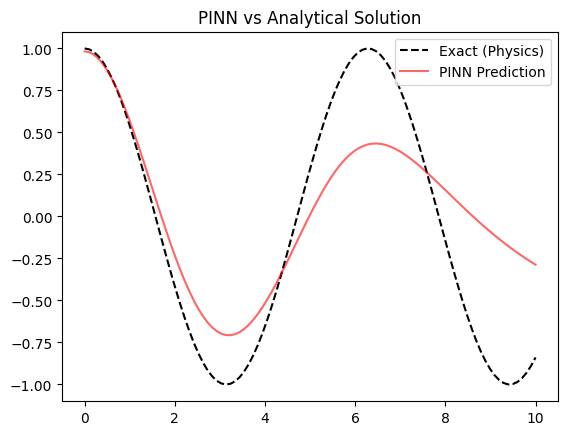

In [6]:
t_test = torch.linspace(0, 10, 100).view(-1, 1)
x_pred = model(t_test).detach().numpy()
x_true = np.cos(t_test.numpy()) # Analytical solution to x'' + x = 0

plt.plot(t_test, x_true, label="Exact (Physics)", color='black', linestyle='--')
plt.plot(t_test, x_pred, label="PINN Prediction", color='red', alpha=0.6)
plt.legend()
plt.title("PINN vs Analytical Solution")
plt.show()